# **Install Required Library**

In [4]:
# Install scikit-fuzzy library
!pip install -q scikit-fuzzy

# **Import Libraries**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import skfuzzy as fuzz

# **Load dataset**

In [6]:
# Load dataset
df = pd.read_csv("smart_home_fcm_dataset_250.csv")

# Display first five rows
df.head()

,Temperature_C,Humidity_pct,CO2_ppm,Light_Lux,Noise_dB,Occupancy
0,21.71,40.96,536.64,784.24,31.23,0
1,22.66,40.40,523.96,713.91,33.39,2
2,23.31,42.66,461.40,578.24,33.48,2
3,22.08,41.36,613.81,525.57,30.13,1
4,23.75,40.56,595.19,729.79,36.69,0


# **Basic Information**

In [7]:
print("Shape of Dataset :", df.shape)

print("\nColumn Names\n")
print(df.columns)

print("\nData Types\n")
print(df.dtypes)

print("\nMissing Values\n")
print(df.isnull().sum())

Shape of Dataset : (250, 6)

Column Names

Index(['Temperature_C', 'Humidity_pct', 'CO2_ppm', 'Light_Lux', 'Noise_dB',
       'Occupancy'],
      dtype='object')

Data Types

Temperature_C    float64
Humidity_pct     float64
CO2_ppm          float64
Light_Lux        float64
Noise_dB         float64
Occupancy          int64
dtype: object

Missing Values

Temperature_C    0
Humidity_pct     0
CO2_ppm          0
Light_Lux        0
Noise_dB         0
Occupancy        0
dtype: int64


# **Statistical Summary**

In [8]:
df.describe()

,Temperature_C,Humidity_pct,CO2_ppm,Light_Lux,Noise_dB,Occupancy
count,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,27.433360,56.11828,995.734000,462.517680,48.242600,4.324000
std,4.976583,13.26327,411.342124,218.330482,14.946448,3.079115
min,17.250000,31.91000,350.000000,0.000000,20.000000,0.000000
25%,23.232500,44.91250,631.147500,289.260000,35.755000,2.000000
50%,26.560000,55.01500,933.665000,468.190000,47.940000,4.000000
75%,32.145000,68.01000,1346.267500,637.215000,59.702500,7.000000
max,37.820000,89.27000,1990.990000,941.190000,79.170000,11.000000


# **Feature Scaling**

In [9]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_data[:5]

array([[-1.15236517, -1.14516913, -1.11832688,  1.47651257, -1.1405203 ,
        -1.40711677],
       [-0.96108821, -1.18747569, -1.14921463,  1.15374003, -0.99571446,
        -0.75627645],
       [-0.8302145 , -1.01673849, -1.30160724,  0.53109607, -0.98968088,
        -0.75627645],
       [-1.07786783, -1.11495016, -0.93034514,  0.28937235, -1.21426402,
        -1.08169661],
       [-0.74162306, -1.1753881 , -0.97570241,  1.22661971, -0.77448331,
        -1.40711677]])

# **Convert Data for FCM**

In [10]:
# ------------------------------------------------------------
# Transpose the scaled dataset
# ------------------------------------------------------------

# After scaling, the dataset has the shape:
# (Number of Samples, Number of Features)
#
# In our dataset:
# 250 samples × 6 features
#
# Shape = (250, 6)
#
# However, the scikit-fuzzy implementation of Fuzzy C-Means
# expects the data in a different format:
#
# (Number of Features, Number of Samples)
#
# Shape = (6, 250)
#
# Therefore, we transpose (.T) the dataset.
#
# Example:
#
# Before Transpose
# ----------------
#               Temp  Humidity  CO2  Light  Noise  Occupancy
# Sample 1
# Sample 2
# Sample 3
# ...
#
# Shape = (250, 6)
#
# After Transpose
# ----------------
#                Sample1 Sample2 Sample3 ...
# Temperature
# Humidity
# CO2
# Light
# Noise
# Occupancy
#
# Shape = (6, 250)
#
# This is the format required by skfuzzy.cluster.cmeans().

data = scaled_data.T

# Display the shape of the transposed dataset
print("Shape after transpose:", data.shape)

Shape after transpose: (6, 250)


# **Apply Fuzzy C-Means**

In [11]:
# ------------------------------------------------------------
# Apply Fuzzy C-Means (FCM) Clustering
# ------------------------------------------------------------

# Define the number of clusters (C)
# Here, we want the algorithm to divide the dataset into 3 clusters.
# You can change this value depending on your problem.
n_clusters = 3


# Run the Fuzzy C-Means (FCM) algorithm
#
# This function performs the complete FCM process:
#
# Step 1: Randomly initialize the membership matrix.
# Step 2: Calculate cluster centers (centroids).
# Step 3: Calculate the distance of every sample from every cluster center.
# Step 4: Update the membership values.
# Step 5: Repeat Steps 2–4 until convergence
#         (or until the maximum number of iterations is reached).

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(

    # --------------------------------------------------------
    # Input dataset
    # --------------------------------------------------------
    # The data must have the shape:
    # (Number of Features × Number of Samples)
    #
    # In our example:
    # Shape = (6, 250)
    #
    # where
    # 6   = Features
    # 250 = Samples
    data=data,

    # --------------------------------------------------------
    # Number of clusters to create
    # --------------------------------------------------------
    # Here we ask FCM to divide the data into 3 clusters.
    c=n_clusters,

    # --------------------------------------------------------
    # Fuzziness coefficient (m)
    # --------------------------------------------------------
    # Controls how "soft" the clustering is.
    #
    # m = 1
    #   Almost behaves like Hard Clustering (K-Means).
    #
    # m = 2
    #   Standard choice used in most research papers.
    #
    # Larger m
    #   Makes memberships more evenly distributed among clusters.
    #
    # Example:
    #
    # m = 2
    # Sample A
    # Cluster1 = 0.90
    # Cluster2 = 0.10
    #
    # m = 5
    # Sample A
    # Cluster1 = 0.60
    # Cluster2 = 0.40
    #
    m=2,

    # --------------------------------------------------------
    # Convergence criterion
    # --------------------------------------------------------
    # The algorithm keeps updating the membership matrix.
    #
    # When the change between two consecutive iterations
    # becomes smaller than 0.005 (Tolerance value),
    # the algorithm stops.
    #
    # Smaller value
    # → More accurate
    # → More iterations
    #
    error=0.005,  #Tolerance value

    # --------------------------------------------------------
    # Maximum number of iterations
    # --------------------------------------------------------
    # Safety limit.
    #
    # If convergence is not reached before 1000 iterations,
    # the algorithm stops automatically.
    #
    maxiter=1000,

    # --------------------------------------------------------
    # Initial membership matrix
    # --------------------------------------------------------
    # init=None means:
    #
    # "Generate the initial membership matrix automatically."
    #
    # Since we don't know the memberships beforehand,
    # FCM starts with random membership values.
    #
    # Example (internally):
    #
    # Sample1
    # Cluster1 = 0.55
    # Cluster2 = 0.30
    # Cluster3 = 0.15
    #
    # Every sample's memberships always sum to 1.
    #
    init=None
)

# **Understand Outputs**

In [12]:
# ------------------------------------------------------------
# Display the Final Cluster Centers (Centroids)
# ------------------------------------------------------------

# 'cntr' contains the coordinates of the final cluster centers.
#
# Since our dataset has 6 features, each cluster center
# contains 6 values representing the average location of that cluster.
#
# Example:
# Cluster 1
# Temperature = 22.5°C
# Humidity    = 43.2%
# CO2         = 560 ppm
# Light       = 710 Lux
# Noise       = 31 dB
# Occupancy   = 1
#
# Note:
# These values are currently STANDARDIZED because we scaled the data
# before applying FCM. We will convert them back to the original units later.

print("=" * 60)
print("Final Cluster Centers (Standardized Values)")
print("=" * 60)
print(cntr)


# ------------------------------------------------------------
# Display the Shape of the Membership Matrix
# ------------------------------------------------------------

# 'u' is the final membership matrix.
#
# Shape = (Number of Clusters, Number of Samples)
#
# In our example:
#
# 3 Clusters
# 250 Samples
#
# Shape = (3, 250)
#
# This means:
#
# Row 1 → Membership values of ALL samples in Cluster 1
# Row 2 → Membership values of ALL samples in Cluster 2
# Row 3 → Membership values of ALL samples in Cluster 3
#
# Every column represents one sample.
#
# Example:
#
#           Sample1 Sample2 Sample3
# Cluster1   0.95     0.10     0.02
# Cluster2   0.04     0.82     0.20
# Cluster3   0.01     0.08     0.78
#
# Notice:
# Each COLUMN sums to 1 because every sample belongs to
# all clusters with different membership values.

print("\n" + "=" * 60)
print("Membership Matrix Shape")
print("=" * 60)
print(u.shape)


# ------------------------------------------------------------
# Display the Fuzzy Partition Coefficient (FPC)
# ------------------------------------------------------------

# FPC measures the quality of fuzzy clustering.
#
# Range:
# 0 ≤ FPC ≤ 1
#
# Higher FPC
# → Better separated clusters
#
# Lower FPC
# → More overlap between clusters
#
# Typical Interpretation:
#
# FPC ≈ 1.0  → Excellent clustering
# FPC > 0.8  → Good clustering
# FPC 0.6–0.8 → Moderate overlap
# FPC < 0.6  → Significant overlap
#
# Note:
# FPC should NOT be compared across different datasets.
# It is mainly useful for comparing different numbers of clusters (C)
# on the SAME dataset.

print("\n" + "=" * 60)
print("Fuzzy Partition Coefficient (FPC)")
print("=" * 60)
print(fpc)

Final Cluster Centers (Standardized Values)
[[-0.12879241 -0.11610565 -0.11794555  0.04497709 -0.03990338 -0.13277996]
 [-1.0072732  -1.00140378 -1.01548209  0.96841418 -1.0062244  -0.96405329]
 [ 1.15527758  1.12309345  1.17111079 -1.03003963  1.0950994   1.15176103]]

Membership Matrix Shape
(3, 250)

Fuzzy Partition Coefficient (FPC)
0.677524812263587


# **Membership Matrix**

In [13]:
# ------------------------------------------------------------
# Convert the Membership Matrix into a Pandas DataFrame
# ------------------------------------------------------------

# The variable 'u' returned by the FCM algorithm is the final
# membership matrix.
#
# Shape of u:
#
# (Number of Clusters × Number of Samples)
#
# In our example:
#
# 3 Clusters
# 250 Samples
#
# Shape = (3,250)
#
# Example:
#
#             Sample1 Sample2 Sample3 ...
# Cluster1      0.95    0.10    0.05
# Cluster2      0.03    0.82    0.20
# Cluster3      0.02    0.08    0.75
#
# Although this format is convenient for the algorithm,
# it is difficult for humans to read because
# each COLUMN represents one sample.

# ------------------------------------------------------------
# Transpose (.T)
# ------------------------------------------------------------

# Transposing changes the shape from
#
# (3,250)
#
# to
#
# (250,3)
#
# Now:
#
# Each ROW = One sample
# Each COLUMN = One cluster
#
# Example:
#
# Sample    Cluster1   Cluster2   Cluster3
# -----------------------------------------
# Sample1     0.95       0.03       0.02
# Sample2     0.10       0.82       0.08
# Sample3     0.05       0.20       0.75
#
# This format is much easier to understand.

membership = pd.DataFrame(

    # Transpose the membership matrix
    u.T,

    # Give meaningful names to each column
    columns=[f"Cluster_{i+1}" for i in range(n_clusters)]
)

# ------------------------------------------------------------
# Display the first five samples
# ------------------------------------------------------------

# head() displays only the first five rows.
# This helps us inspect the membership values without
# printing all 250 samples.

membership.head()

,Cluster_1,Cluster_2,Cluster_3
0,0.060728,0.924802,0.014470
1,0.023646,0.971761,0.004593
2,0.075059,0.912267,0.012674
3,0.098048,0.883813,0.018139
4,0.066555,0.919976,0.013469


# **PCA Visualization**

In [14]:
# ------------------------------------------------------------
# Apply Principal Component Analysis (PCA)
# ------------------------------------------------------------

# Our dataset originally has 6 features:
#
# 1. Temperature
# 2. Humidity
# 3. CO₂
# 4. Light
# 5. Noise
# 6. Occupancy
#
# Therefore, each sample is represented as a point in
# 6-dimensional space.
#
# Humans cannot visualize data beyond 3 dimensions.
# So, we use PCA (Principal Component Analysis) to reduce
# the number of dimensions while preserving as much information
# (variance) as possible.

# ------------------------------------------------------------
# Create a PCA object
# ------------------------------------------------------------

# n_components = 2 means:
#
# Reduce the original 6-dimensional dataset
#
#        (6 Features)
#
#               ↓
#
#        (2 Principal Components)
#
# These two new variables are called:
#
# Principal Component 1 (PC1)
# Principal Component 2 (PC2)
#
# They are combinations of the original features and capture
# most of the important information present in the dataset.

pca = PCA(n_components=2)

# ------------------------------------------------------------
# Fit PCA and Transform the Data
# ------------------------------------------------------------

# fit_transform() performs two operations:
#
# Step 1: Learn the directions (principal components) that
#         capture the maximum variance in the data.
#
# Step 2: Project each sample from 6-dimensional space into
#         2-dimensional space.
#
# Before PCA:
#
# Shape = (250, 6)
#
# 250 Samples
# 6 Features
#
# After PCA:
#
# Shape = (250, 2)
#
# Each sample is now represented using only:
#
# PC1
# PC2
#
# Example:
#
# Original Sample
#
# (25, 45, 650, 700, 35, 2)
#
# becomes
#
# (-1.42, 0.87)
#
# These new values are not Temperature or Humidity.
# They are coordinates in the new 2-dimensional PCA space.

reduced = pca.fit_transform(scaled_data)

# ------------------------------------------------------------
# Display the shape of the transformed dataset
# ------------------------------------------------------------

print("Original Data Shape :", scaled_data.shape)
print("Reduced Data Shape  :", reduced.shape)

Original Data Shape : (250, 6)
Reduced Data Shape  : (250, 2)


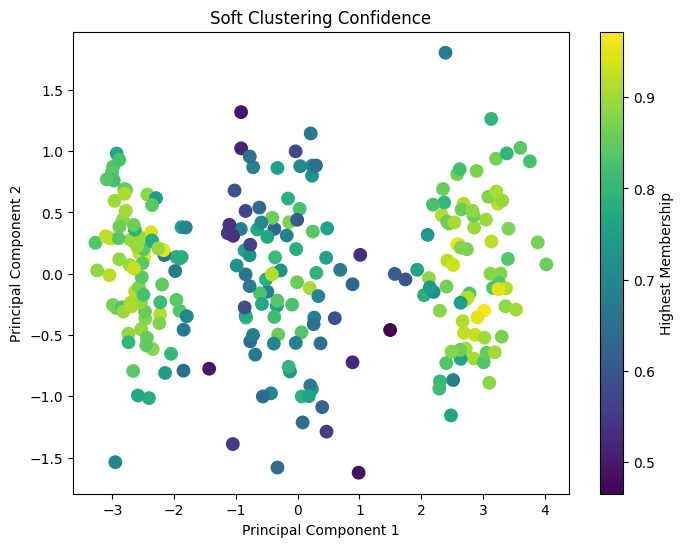

In [15]:
# ------------------------------------------------------------
# Visualize Soft Clustering Confidence
# ------------------------------------------------------------

# 'reduced' contains the dataset after applying PCA.
# PCA reduces our original 6-dimensional data into 2 dimensions
# so that we can visualize it on a 2D scatter plot.
#
# Each point in the graph represents one sample (one room).

plt.figure(figsize=(8,6))


# Create a scatter plot
scatter = plt.scatter(

    # X-axis:
    # First Principal Component (PC1)
    reduced[:,0],

    # Y-axis:
    # Second Principal Component (PC2)
    reduced[:,1],

    # Color of each point
    #
    # np.max(u, axis=0) finds the highest membership value
    # for each sample.
    #
    # Example:
    #
    # Sample 1
    # Cluster1 = 0.95
    # Cluster2 = 0.03
    # Cluster3 = 0.02
    #
    # Maximum membership = 0.95
    #
    # This value represents how confidently the sample belongs
    # to its most likely cluster.
    #
    # Higher value (close to 1)
    # → Strong confidence
    #
    # Lower value (close to 0.5)
    # → Sample lies between clusters
    c=np.max(u, axis=0),

    # Size of each point
    s=80,

    # Color map used for coloring the points
    #
    # Viridis:
    # Dark Blue → Low confidence
    # Green     → Medium confidence
    # Yellow    → High confidence
    cmap='viridis'
)


# Add a color scale beside the graph.
# It helps interpret what each color represents.
#
# Example:
# Yellow → Membership ≈ 1.0
# Blue   → Membership ≈ 0.4

plt.colorbar(label="Highest Membership")


# Add graph title
plt.title("Soft Clustering Confidence")


# Label X-axis
plt.xlabel("Principal Component 1")


# Label Y-axis
plt.ylabel("Principal Component 2")


# Display the plot
plt.show()

# **Final Cluster Assignment**

Choose

Highest Membership

In [16]:
# ------------------------------------------------------------
# Convert Soft Clustering into Hard Clustering
# ------------------------------------------------------------

# The membership matrix 'u' has the shape:
#
# (Number of Clusters × Number of Samples)
#
# In our example:
#
# Shape = (3, 250)
#
# Example:
#
#             Sample1 Sample2 Sample3
# Cluster_1     0.95    0.10    0.05
# Cluster_2     0.03    0.82    0.20
# Cluster_3     0.02    0.08    0.75
#
# Every sample belongs to ALL clusters,
# but with different membership values.

# ------------------------------------------------------------
# Find the Cluster with the Highest Membership
# ------------------------------------------------------------

# np.argmax() returns the index of the largest value.
#
# axis=0 means:
# "Look down each column (each sample)."
#
# Example:
#
# Sample 1
#
# Cluster_1 = 0.95
# Cluster_2 = 0.03
# Cluster_3 = 0.02
#
# Highest membership = 0.95
#
# Therefore,
#
# Sample 1 is assigned to Cluster 1.
#
# Another example:
#
# Cluster_1 = 0.20
# Cluster_2 = 0.70
# Cluster_3 = 0.10
#
# Highest membership = 0.70
#
# Therefore,
#
# Sample belongs to Cluster 2.

cluster_labels = np.argmax(u, axis=0)

# The output looks like:
#
# [0, 1, 2, 0, 1, 2, ...]
#
# Note:
# Python starts indexing from 0.
#
# 0 → Cluster 1
# 1 → Cluster 2
# 2 → Cluster 3


# ------------------------------------------------------------
# Store the Final Cluster Label in the Original Dataset
# ------------------------------------------------------------

# Adding +1 converts Python indexing into human-readable labels.
#
# Before:
#
# 0
# 1
# 2
#
# After:
#
# 1
# 2
# 3

df["Cluster"] = cluster_labels + 1


# ------------------------------------------------------------
# Display the Updated Dataset
# ------------------------------------------------------------

# The dataset now contains an additional column called "Cluster",
# indicating the final cluster assigned to each sample.
#
# Example:
#
# Temperature  Humidity  CO₂   ...   Cluster
# ------------------------------------------
#     25          45     650          1
#     30          68    1400          3
#     22          40     500          2

df.head()

,Temperature_C,Humidity_pct,CO2_ppm,Light_Lux,Noise_dB,Occupancy,Cluster
0,21.71,40.96,536.64,784.24,31.23,0,2
1,22.66,40.40,523.96,713.91,33.39,2,2
2,23.31,42.66,461.40,578.24,33.48,2,2
3,22.08,41.36,613.81,525.57,30.13,1,2
4,23.75,40.56,595.19,729.79,36.69,0,2


# **Number of Points in Each Cluster**

In [17]:
# ------------------------------------------------------------
# Count the Number of Samples in Each Cluster
# ------------------------------------------------------------

# The "Cluster" column contains the final hard cluster labels
# assigned using the highest membership value.
#
# Example:
#
# Sample    Cluster
# -----------------
# 1            1
# 2            2
# 3            3
# 4            1
# 5            2
# ...

# value_counts() counts how many samples belong to each cluster.
#
# Example Output (before sorting):
#
# Cluster
# 3    82
# 1    88
# 2    80
#
# Notice that the clusters may not appear in numerical order.

# sort_index() sorts the clusters based on their cluster number.
#
# Final Output:
#
# Cluster
# 1    88
# 2    80
# 3    82
#
# This tells us:
# Cluster 1 contains 88 samples.
# Cluster 2 contains 80 samples.
# Cluster 3 contains 82 samples.

print("Number of Samples in Each Cluster")
print("=" * 40)

print(df["Cluster"].value_counts().sort_index())

Number of Samples in Each Cluster
Cluster
1    86
2    82
3    82
Name: count, dtype: int64


# **Cluster Centers**

In [18]:
# ------------------------------------------------------------
# Convert Cluster Centers Back to Original Scale
# ------------------------------------------------------------

# The Fuzzy C-Means algorithm was applied on the STANDARDIZED data.
#
# Therefore, the cluster centers (cntr) are also in the
# standardized (scaled) space.
#
# Example:
#
# Temperature = 1.15
# Humidity    = -0.82
# CO₂         = 0.94
#
# These values represent Z-scores (standardized values),
# not the original units (°C, %, ppm, etc.).
#
# To make the cluster centers easy to understand,
# we convert them back to the original feature values
# using the scaler's inverse_transform() method.

cluster_centers = scaler.inverse_transform(cntr)

# ------------------------------------------------------------
# Convert the Cluster Centers into a Pandas DataFrame
# ------------------------------------------------------------

# cluster_centers is currently a NumPy array.
#
# We convert it into a DataFrame so that each column
# has a meaningful feature name.
#
# Shape of cluster_centers:
#
# (Number of Clusters × Number of Features)
#
# In our example:
#
# Shape = (3, 6)
#
# Example:
#
#              Temp  Humidity  CO₂  Light  Noise  Occupancy
# Cluster 1
# Cluster 2
# Cluster 3
#
# We use df.columns[:-1] because:
#
# The last column of df is "Cluster",
# which was added after clustering.
#
# We only want the ORIGINAL feature names,
# so we exclude the last column.

cluster_centers = pd.DataFrame(

    cluster_centers,

    # Use only the original feature names
    columns=df.columns[:-1]
)

# ------------------------------------------------------------
# Display the Cluster Centers
# ------------------------------------------------------------

# Each row represents one cluster center.
#
# Each column represents one feature.
#
# These values are now in the ORIGINAL units,
# making them easy to interpret.
#
# Example:
#
#            Temperature  Humidity  CO₂  Light  Noise  Occupancy
# Cluster 1      32.5       72.1   1450   210     65       8
# Cluster 2      22.3       40.5    520   760     30       1
# Cluster 3      27.6       55.2    980   510     45       4
#
# Interpretation:
# - Cluster 1 represents rooms with high temperature,
#   high humidity, high CO₂, low light, high noise,
#   and high occupancy.
#
# - Cluster 2 represents cooler, quieter, and brighter rooms
#   with fewer occupants.
#
# - Cluster 3 represents average room conditions.

print("Cluster Centers in Original Feature Space")
print("=" * 70)

cluster_centers

Cluster Centers in Original Feature Space


,Temperature_C,Humidity_pct,CO2_ppm,Light_Lux,Noise_dB,Occupancy
0,26.793697,54.581422,947.315157,472.317890,47.647380,3.915974
1,22.430617,42.862981,578.859701,673.528722,33.233228,1.361512
2,33.171185,70.984350,1476.496780,238.078859,64.577678,7.863304


# **Plot Clusters**

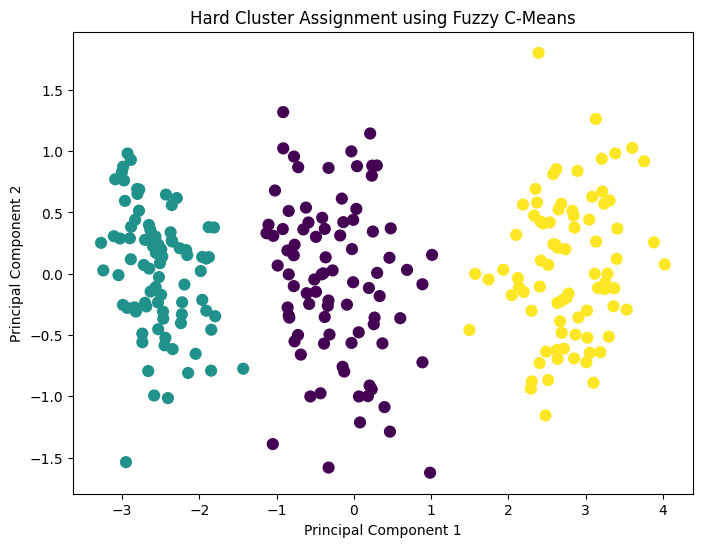

In [19]:
# ------------------------------------------------------------
# Visualize the Final Hard Clusters
# ------------------------------------------------------------

# The original dataset had 6 features.
#
# Since humans cannot visualize 6-dimensional data,
# we previously used PCA to reduce the data into
# 2 dimensions (Principal Component 1 and Principal Component 2).
#
# 'reduced' has the shape:
#
# (250, 2)
#
# where:
# Column 1 = Principal Component 1 (PC1)
# Column 2 = Principal Component 2 (PC2)

plt.figure(figsize=(8,6))


# ------------------------------------------------------------
# Create a Scatter Plot
# ------------------------------------------------------------

# Each point in the graph represents one sample
# from the original dataset.

plt.scatter(

    # X-axis
    # First Principal Component
    reduced[:,0],

    # Y-axis
    # Second Principal Component
    reduced[:,1],

    # Assign a different color to each cluster.
    #
    # cluster_labels contains the hard cluster assignment
    # obtained using:
    #
    # cluster_labels = np.argmax(u, axis=0)
    #
    # Example:
    #
    # Sample 1 → Cluster 1
    # Sample 2 → Cluster 2
    # Sample 3 → Cluster 3
    #
    # The color represents the final cluster assigned
    # to each sample.
    c=cluster_labels,

    # Size of each point
    s=60
)


# ------------------------------------------------------------
# Label the X-axis
# ------------------------------------------------------------

plt.xlabel("Principal Component 1")


# ------------------------------------------------------------
# Label the Y-axis
# ------------------------------------------------------------

plt.ylabel("Principal Component 2")


# ------------------------------------------------------------
# Add a title
# ------------------------------------------------------------

plt.title("Hard Cluster Assignment using Fuzzy C-Means")


# ------------------------------------------------------------
# Display the graph
# ------------------------------------------------------------

plt.show()

# **Visualize Membership Values**

In [20]:
membership.head(10)

,Cluster_1,Cluster_2,Cluster_3
0,0.060728,0.924802,0.014470
1,0.023646,0.971761,0.004593
2,0.075059,0.912267,0.012674
3,0.098048,0.883813,0.018139
4,0.066555,0.919976,0.013469
5,0.122196,0.847496,0.030307
6,0.103334,0.875958,0.020708
7,0.049230,0.941766,0.009004
8,0.092871,0.885259,0.021870
9,0.132139,0.833761,0.034100


# **Check Membership Sum**

In [21]:
membership.sum(axis=1).head()

,0
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


# **Fuzzy Partition Coefficient**

In [22]:
# ------------------------------------------------------------
# Display the Fuzzy Partition Coefficient (FPC)
# ------------------------------------------------------------

# The Fuzzy Partition Coefficient (FPC) is a metric used to
# evaluate the quality of the fuzzy clustering.
#
# It measures how clearly the samples are separated into clusters.
#
# Range:
#
# 0 ≤ FPC ≤ 1
#
# Interpretation:
#
# FPC close to 1
# → Samples strongly belong to one cluster.
# → Clusters are well separated.
#
# FPC close to 0
# → Samples have similar membership values across multiple clusters.
# → Clusters overlap significantly.
#
# General Guideline:
#
# FPC > 0.90  → Excellent clustering
# FPC 0.80-0.90 → Good clustering
# FPC 0.60-0.80 → Moderate clustering
# FPC < 0.60  → Significant overlap between clusters
#
# Note:
# FPC is mainly used to compare different numbers of clusters
# (e.g., C = 2, 3, 4, 5) on the SAME dataset.
#
# The number of clusters with the highest FPC is often
# considered the best choice.

print("=" * 50)
print("Fuzzy Partition Coefficient (FPC)")
print("=" * 50)
print(f"FPC Score: {fpc:.4f}")

Fuzzy Partition Coefficient (FPC)
FPC Score: 0.6775


# **Objective Function**

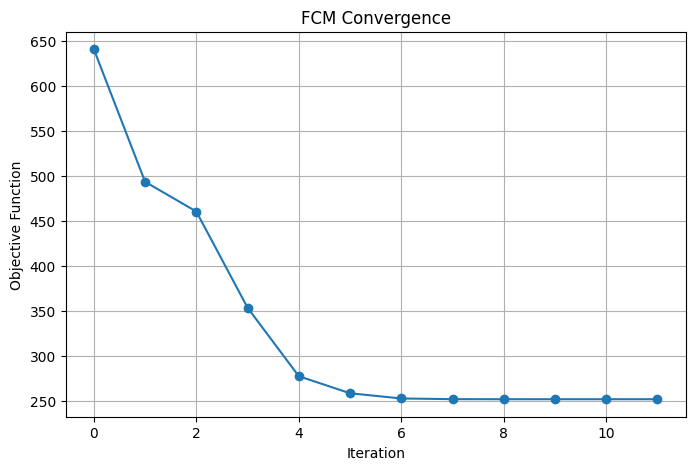

In [23]:
plt.figure(figsize=(8,5))

plt.plot(jm, marker='o')

plt.xlabel("Iteration")
plt.ylabel("Objective Function")

plt.title("FCM Convergence")

plt.grid(True)

plt.show()